In [1]:
from pydicom import dcmread
from pydicom.data import get_testdata_files
import pandas as pd
import numpy as np
import os
import torch
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras import regularizers

In [2]:
df = pd.read_csv('train2.csv')

In [3]:
df

,ID,Disease
0,1067739,1
1,1038067,0
2,422411,1
3,91553,1
4,1047213,1
...,...,...
155,651657,1
156,436524,1
157,148593,1
158,1057213,1


In [4]:
train = df.sample(frac=0.7, replace=False,random_state= 10)

In [5]:
train

,ID,Disease
35,645706,1
132,3000485,1
47,1038449,0
24,5008735,1
90,666215,0
...,...,...
17,926877,0
118,3015828,1
148,279670,1
71,321605,0


In [6]:
train['Disease'].value_counts() # balanced

0    57
1    55
Name: Disease, dtype: int64

In [7]:
x = train['ID'].values

In [8]:
L = []
for i in range(len(x)):
    if len(str(x[i])) < 7:
        t = '0'* (7- len(str(x[i])))
        file = t + str(x[i])
    else:
        file = str(x[i])
    L.append(file)

In [9]:
train['ID'] = L
train

,ID,Disease
35,0645706,1
132,3000485,1
47,1038449,0
24,5008735,1
90,0666215,0
...,...,...
17,0926877,0
118,3015828,1
148,0279670,1
71,0321605,0


In [10]:
T1 = [] 
for i in train['ID']:
    path = 'C:\\Users\\James\\DICOM2\\'+ i +'\\T1'
    os.chdir(path) #到指定資料夾
    x = os.listdir()
    data = [0]*len(x)
    for j in x:
        ds = dcmread(j)
        WC = ds.WindowCenter
        WW = ds.WindowWidth
        H = (int(ds.WindowCenter)*2 + int(ds.WindowWidth)) / 2
        L = H - int(ds.WindowWidth)
        arr = np.array(ds.pixel_array)
        arr = arr[106:406,106:406]
        arr[arr > H] = H
        arr[arr < L] = L
        arr = 255*((arr-L)/int(WW)) 
        data[int(ds.InstanceNumber)-1] = arr
    data = np.array(data)
    x_np = torch.from_numpy(data)
    x_np = x_np[None, None, :]
    x_np = torch.nn.functional.interpolate(x_np, size= [22,150,150], scale_factor=None, mode='trilinear')
    x_np = torch.reshape(x_np, (22,150,150))
    x_np = x_np.numpy()
    T1.append(x_np)

In [11]:
T1 = np.array(T1)
T1.shape

(112, 22, 150, 150)

In [12]:
T2 = [] 
for i in train['ID']:
    path = 'C:\\Users\\James\\DICOM2\\'+ i +'\\T2'
    os.chdir(path) #到指定資料夾
    y = os.listdir()
    data = [0]*len(y)
    for j in y:
        ds = dcmread(j)
        WC = ds.WindowCenter
        WW = ds.WindowWidth
        H = (int(ds.WindowCenter)*2 + int(ds.WindowWidth)) / 2
        L = H - int(ds.WindowWidth)
        arr = np.array(ds.pixel_array)
        arr = arr[106:406,106:406]
        arr[arr > H] = H
        arr[arr < L] = L
        arr = 255*((arr-L)/int(WW)) 
        data[int(ds.InstanceNumber)-1] = arr
    data = np.array(data)
    y_np = torch.from_numpy(data)
    y_np = y_np[None, None, :]
    y_np = torch.nn.functional.interpolate(y_np, size= [22,150,150], scale_factor=None, mode='trilinear')
    y_np = torch.reshape(y_np, (22,150,150))
    y_np = y_np.numpy()
    T2.append(y_np)

In [13]:
T2 = np.array(T2)
T2.shape

(112, 22, 150, 150)

In [14]:
X_train = []
for i in range(len(T1)):
    x = T1[i]
    y = T2[i]
    z = (T1[i]+T2[i])/2
    i1 = np.expand_dims(x,axis=3)
    i2 = np.expand_dims(y,axis=3)
    i3 = np.expand_dims(z,axis=3)
    image = np.concatenate((i1,i2,i3),axis=-1)
    image = image / 255
    X_train.append(image)

In [15]:
X_train = np.array(X_train)
X_train.shape  #(N,D,H,W,Channel)

(112, 22, 150, 150, 3)

In [16]:
X_train.shape[0]

112

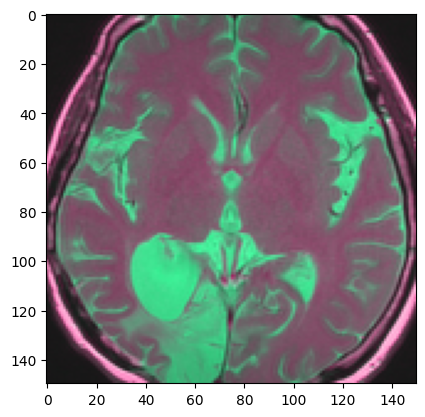

In [17]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0][10])
plt.show()

In [18]:
y_train = np.array(train.Disease)

In [19]:
y_train

array([1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1], dtype=int64)

In [20]:
index = train.index

In [21]:
#validation set
val_index = []
for i in range(160):
    if i not in index:
        val_index.append(i)

In [22]:
vali_ID = []
vali_disease = []

for i in range(48):
    top = val_index[i]
    ID = df.at[top, 'ID']
    Disease = df.at[top, 'Disease']
    vali_ID.append(ID)
    vali_disease.append(Disease)

In [23]:
# dictionary of lists 
dict = {'ID': vali_ID, 'Disease': vali_disease}     
valid = pd.DataFrame(dict)    
valid.head()

,ID,Disease
0,1067739,1
1,976869,0
2,4194,0
3,261016,1
4,1008632,0


In [24]:
x2 = valid['ID'].values

In [25]:
L2 = []
for i in range(len(x2)):
    if len(str(x2[i])) < 7:
        t = '0'* (7- len(str(x2[i])))
        file2 = t + str(x2[i])
    else:
        file2 = str(x2[i])
    L2.append(file2)

In [26]:
valid['ID'] = L2
valid

,ID,Disease
0,1067739,1
1,0976869,0
2,0004194,0
3,0261016,1
4,1008632,0
5,0910626,0
6,0004725,0
7,0145799,1
8,0455658,0
9,0862127,1


In [27]:
T1_valid = [] 
for i in valid['ID']:
    path = 'C:\\Users\\James\\DICOM2\\'+ i +'\\T1'
    os.chdir(path) #到指定資料夾
    x = os.listdir()
    data = [0]*len(x)
    for j in x:
        ds = dcmread(j)
        WC = ds.WindowCenter
        WW = ds.WindowWidth
        H = (int(ds.WindowCenter)*2 + int(ds.WindowWidth)) / 2
        L = H - int(ds.WindowWidth)
        arr = np.array(ds.pixel_array)
        arr = arr[106:406,106:406]
        arr[arr > H] = H
        arr[arr < L] = L
        arr = 255*((arr-L)/int(WW)) 
        data[int(ds.InstanceNumber)-1] = arr
    data = np.array(data)
    x_np = torch.from_numpy(data)
    x_np = x_np[None, None, :]
    x_np = torch.nn.functional.interpolate(x_np, size= [22,150,150], scale_factor=None, mode='trilinear')
    x_np = torch.reshape(x_np, (22,150,150))
    x_np = x_np.numpy()
    T1_valid.append(x_np)

In [28]:
T2_valid = [] 
for i in valid['ID']:
    path = 'C:\\Users\\James\\DICOM2\\'+ i +'\\T2'
    os.chdir(path) #到指定資料夾
    x = os.listdir()
    data = [0]*len(x)
    for j in x:
        ds = dcmread(j)
        WC = ds.WindowCenter
        WW = ds.WindowWidth
        H = (int(ds.WindowCenter)*2 + int(ds.WindowWidth)) / 2
        L = H - int(ds.WindowWidth)
        arr = np.array(ds.pixel_array)
        arr = arr[106:406,106:406]
        arr[arr > H] = H
        arr[arr < L] = L
        arr = 255*((arr-L)/int(WW)) 
        data[int(ds.InstanceNumber)-1] = arr
    data = np.array(data)
    x_np = torch.from_numpy(data)
    x_np = x_np[None, None, :]
    x_np = torch.nn.functional.interpolate(x_np, size= [22,150,150], scale_factor=None, mode='trilinear')
    x_np = torch.reshape(x_np, (22,150,150))
    x_np = x_np.numpy()
    T2_valid.append(x_np)

In [29]:
T1_valid = np.array(T1_valid)
T2_valid = np.array(T2_valid)


In [30]:
T1_valid.shape

(48, 22, 150, 150)

In [31]:
X_valid = []
for i in range(len(T1_valid)):
    x = T1_valid[i]
    y = T2_valid[i]
    z = (T1_valid[i]+T2_valid[i])/2
    i1 = np.expand_dims(x,axis=3)
    i2 = np.expand_dims(y,axis=3)
    i3 = np.expand_dims(z,axis=3)
    image = np.concatenate((i1,i2,i3),axis=-1)
    image = image / 255
    X_valid.append(image)

X_valid = np.array(X_valid)

In [32]:
X_valid.shape  #(N,D,H,W,Channel)

(48, 22, 150, 150, 3)

In [33]:
y_valid = np.array(valid.Disease)

In [34]:
import os
import zipfile
import numpy as np
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

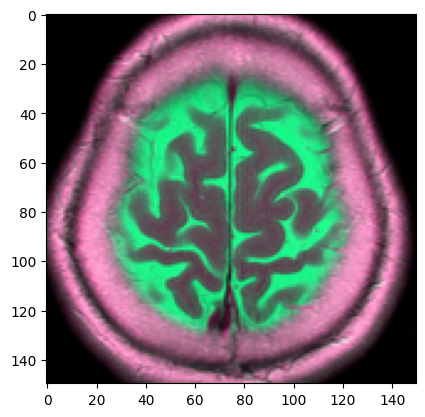

In [35]:
import matplotlib.pyplot as plt

plt.imshow(X_valid[2][18])
plt.show()

In [36]:
import tensorflow_addons as tfa
from tensorflow.keras import layers



C:\Users\James\anaconda3\envs\tf_2.6_py_3.7\lib\site-packages\tensorflow_addons\utils\ensure_tf_install.py:67: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.8.0 and strictly below 2.11.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.6.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If you want to make sure you're using a tested and supported configuration, either change the TensorFlow version or the TensorFlow Addons's version. 
You can find the compatibility matrix in TensorFlow Addon's readme:
https://github.com/tensorflow/addons
  UserWarning,


In [72]:
from tensorflow.keras.utils import Sequence
import numpy as np   

class DataGenerator(Sequence):
    def __init__(self, x_set, y_set, batch_size):
        self.x = x_set
        self.y = y_set
        self.batch_size = batch_size

    def __len__(self):
        return int(np.ceil(len(self.x) / float(self.batch_size)))

    def __getitem__(self, idx):
        batch_x = self.x[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_y = self.y[idx * self.batch_size:(idx + 1) * self.batch_size]
        
        batch_x = np.reshape(batch_x,(self.batch_size, 150, 150, 66))
        return batch_x, batch_y

train_gen = DataGenerator(X_train, y_train, 2)
test_gen = DataGenerator(X_valid, y_valid, 2)

In [73]:
train_gen

In [74]:
import keras
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential, load_model
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.layers import Input, Dense, Dropout

In [81]:
def get_model():
    """Build a 3D convolutional neural network model."""
    
    input1 = Input(shape=(150,150,66)) # input layer
    # preprocessing layer to augmentation
    rand_flip = layers.RandomFlip("horizontal_and_vertical", seed= 1)(input1)
    rand_rote = layers.RandomRotation(factor=0.01, seed= 1)(rand_flip)
    rand_crop = layers.RandomCrop(int(150*0.97), int(150*0.97), seed= 1)(rand_rote)
    re = layers.Reshape((145, 145, 22, 3))(rand_crop) # reshape to 3D
    # conv block
    x = layers.Conv3D(filters=64, kernel_size=(3, 3, 3), padding='same',activation="relu")(re)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool3D(pool_size=2)(x)
    
    x = layers.BatchNormalization()(x)
    x = layers.Conv3D(filters=64, kernel_size=(3, 3, 3), padding='same',activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool3D(pool_size=2)(x)
    
    x = layers.BatchNormalization()(x)
    x = layers.Conv3D(filters=128, kernel_size=(3, 3, 3), padding='same',activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool3D(pool_size=2)(x)
   
    x = layers.BatchNormalization()(x)
    x = layers.Conv3D(filters=128, kernel_size=(3, 3, 3), padding='same',activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool3D(pool_size=2)(x)
    
    # FC layers
    x = layers.GlobalAveragePooling3D()(x) # flatten
    x = layers.Dense(units=1024, activation="relu", kernel_regularizer=regularizers.L1(0.01))(x) 
    x = Dropout(0.5)(x)
    x = layers.Dense(units=512, activation="relu", kernel_regularizer=regularizers.L1(0.01))(x)
    x = Dropout(0.2)(x)
    x = layers.Dense(units=32, activation="relu")(x)
    outputs = layers.Dense(units=1, activation="sigmoid")(x) #fc

    # Define the model.
    model = keras.Model(input1, outputs, name="3dcnn")
    return model


# Build model.
model = get_model()
model.summary()

Model: "3dcnn"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_6 (InputLayer)         [(None, 150, 150, 66)]    0         
_________________________________________________________________
random_flip_5 (RandomFlip)   (None, 150, 150, 66)      0         
_________________________________________________________________
random_rotation_5 (RandomRot (None, 150, 150, 66)      0         
_________________________________________________________________
random_crop_5 (RandomCrop)   (None, 145, 145, 66)      0         
_________________________________________________________________
reshape_5 (Reshape)          (None, 145, 145, 22, 3)   0         
_________________________________________________________________
conv3d_20 (Conv3D)           (None, 145, 145, 22, 64)  5248      
_________________________________________________________________
batch_normalization_23 (Batc (None, 145, 145, 22, 64)  256   

In [82]:
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=1e-4, decay=0.0) #優化採用adam ，起始直因batch size小。取小一點。

In [83]:
model.compile(
    loss="binary_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"],
)

In [84]:
from keras.callbacks import EarlyStopping


callback = EarlyStopping(
    monitor="val_accuracy",
    min_delta=0,
    patience=15,
    verbose=0,
    mode="max")


In [85]:
# lr scheduler 每過10個epoch，降低lr
def scheduler(epoch, lr):
    if epoch < 10:
        return lr
    else:
        return lr * tf.math.exp(-0.1)
callback2 = LearningRateScheduler(scheduler)

In [86]:
from tensorflow import keras
from tensorflow.keras import layers

In [87]:

# Train the model, doing validation at the end of each epoch
epochs = 100
history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=epochs,
    verbose=2,
    callbacks=[callback,callback2],
)


Epoch 1/100
56/56 - 11s - loss: 197.5236 - accuracy: 0.4554 - val_loss: 183.2076 - val_accuracy: 0.4792
Epoch 2/100
56/56 - 6s - loss: 170.1038 - accuracy: 0.5625 - val_loss: 156.8505 - val_accuracy: 0.5208
Epoch 3/100
56/56 - 7s - loss: 144.6202 - accuracy: 0.5536 - val_loss: 132.3590 - val_accuracy: 0.5208
Epoch 4/100
56/56 - 7s - loss: 121.1293 - accuracy: 0.6161 - val_loss: 109.9043 - val_accuracy: 0.5000
Epoch 5/100
56/56 - 7s - loss: 99.7136 - accuracy: 0.5893 - val_loss: 89.5751 - val_accuracy: 0.5208
Epoch 6/100
56/56 - 7s - loss: 80.4523 - accuracy: 0.6250 - val_loss: 71.4471 - val_accuracy: 0.5000
Epoch 7/100
56/56 - 7s - loss: 63.4204 - accuracy: 0.6786 - val_loss: 55.5772 - val_accuracy: 0.5417
Epoch 8/100
56/56 - 7s - loss: 48.6561 - accuracy: 0.6518 - val_loss: 42.0206 - val_accuracy: 0.5208
Epoch 9/100
56/56 - 7s - loss: 36.2925 - accuracy: 0.5625 - val_loss: 30.8332 - val_accuracy: 0.5833
Epoch 10/100
56/56 - 7s - loss: 26.2917 - accuracy: 0.6875 - val_loss: 22.0782 - v

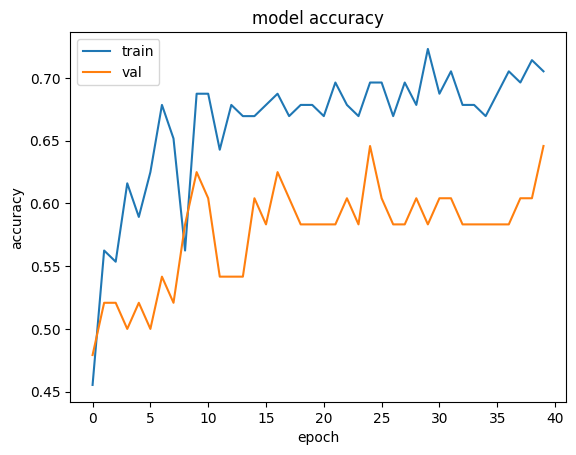

In [88]:
# accuracy curve
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

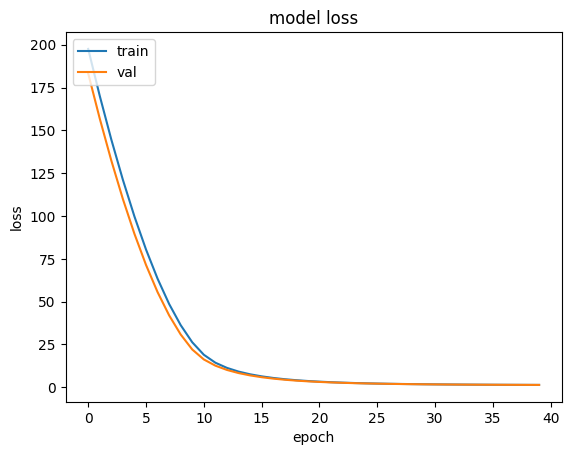

In [89]:
# loss curve
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [90]:
#load test
os.chdir('C:\\Users\\James')
df = pd.read_csv('test2.csv')

In [91]:
x = df['ID'].values

In [92]:
L = []
for i in range(len(x)):
    if len(str(x[i])) < 7:
        t = '0'* (7- len(str(x[i])))
        file = t + str(x[i])
    else:
        file = str(x[i])
    L.append(file)

In [93]:
df['ID'] = L
df

,ID,Disease 0,Disease 1,Disease
0,1035303,NaN,NaN,NaN
1,1032110,NaN,NaN,NaN
2,0003158,NaN,NaN,NaN
3,0759590,NaN,NaN,NaN
4,0903423,NaN,NaN,NaN
5,0629424,NaN,NaN,NaN
6,0984633,NaN,NaN,NaN
7,0908999,NaN,NaN,NaN
8,0011338,NaN,NaN,NaN
9,1070273,NaN,NaN,NaN


In [94]:
T1 = [] 
for i in df['ID']:
    path = 'C:\\Users\\James\\DICOM2\\'+ i +'\\T1'
    os.chdir(path) #到指定資料夾
    x = os.listdir()
    data = [0]*len(x)
    for j in x:
        ds = dcmread(j)
        WC = ds.WindowCenter
        WW = ds.WindowWidth
        H = (int(ds.WindowCenter)*2 + int(ds.WindowWidth)) / 2
        L = H - int(ds.WindowWidth)
        arr = np.array(ds.pixel_array)
        arr = arr[106:406,106:406]
        arr[arr > H] = H
        arr[arr < L] = L
        arr = 255*((arr-L)/int(WW)) 
        data[int(ds.InstanceNumber)-1] = arr
    data = np.array(data)
    x_np = torch.from_numpy(data)
    x_np = x_np[None, None, :]
    x_np = torch.nn.functional.interpolate(x_np, size= [22,150,150], scale_factor=None, mode='trilinear')
    x_np = torch.reshape(x_np, (22,150,150))
    x_np = x_np.numpy()
    T1.append(x_np)

In [95]:
T2 = [] 
for i in df['ID']:
    path = 'C:\\Users\\James\\DICOM2\\'+ i +'\\T2'
    os.chdir(path) #到指定資料夾
    y = os.listdir()
    data = [0]*len(y)
    for j in y:
        ds = dcmread(j)
        WC = ds.WindowCenter
        WW = ds.WindowWidth
        H = (int(ds.WindowCenter)*2 + int(ds.WindowWidth)) / 2
        L = H - int(ds.WindowWidth)
        arr = np.array(ds.pixel_array)
        arr = arr[106:406,106:406]
        arr[arr > H] = H
        arr[arr < L] = L
        arr = 255*((arr-L)/int(WW)) 
        data[int(ds.InstanceNumber)-1] = arr
    data = np.array(data)
    y_np = torch.from_numpy(data)
    y_np = y_np[None, None, :]
    y_np = torch.nn.functional.interpolate(y_np, size= [22,150,150], scale_factor=None, mode='trilinear')
    y_np = torch.reshape(y_np, (22,150,150))
    y_np = y_np.numpy()
    T2.append(y_np)

In [96]:
T2 = np.array(T2)

In [97]:
X_test = []
for i in range(len(T1)):
    x = T1[i]
    y = T2[i]
    z = (T1[i]+T2[i])/2
    i1 = np.expand_dims(x,axis=3)
    i2 = np.expand_dims(y,axis=3)
    i3 = np.expand_dims(z,axis=3)
    image = np.concatenate((i1,i2,i3),axis=-1)
    image = image / 255
    X_test.append(image)

In [98]:
X_test = np.array(X_test)
X_test.shape  #(N,D,H,W,Channel)

(40, 22, 150, 150, 3)

In [100]:
X_test_batch = np.reshape(X_test,(40,150,150,66))

In [101]:
pred =model.predict(
    X_test_batch,
    batch_size= 1)

In [102]:
Disease_1 = pred.flatten()

In [103]:
Disease_1 = np.array(Disease_1)

In [104]:
Disease_0 = np.ones(40) - Disease_1

In [105]:
Disease = []
for i in Disease_1:
    if i > 0.5:
        Disease.append(1)
    else:
        Disease.append(0)

In [106]:
Disease = np.array(Disease)

In [107]:
df.columns = ['ID', 'Disease_0', 'Disease_1', 'Disease']

In [108]:
df['Disease_0'] = Disease_0
df['Disease_1'] = Disease_1
df['Disease'] = Disease


In [109]:
df

,ID,Disease_0,Disease_1,Disease
0,1035303,0.448812,0.551188,1
1,1032110,0.509912,0.490088,0
2,0003158,0.509686,0.490314,0
3,0759590,0.505612,0.494388,0
4,0903423,0.505668,0.494332,0
5,0629424,0.501666,0.498334,0
6,0984633,0.473987,0.526013,1
7,0908999,0.444953,0.555047,1
8,0011338,0.527640,0.472360,0
9,1070273,0.509174,0.490826,0


In [110]:
df.to_csv("conv3D.csv")